In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('✅ pandas:', pd.__version__)
print('✅ matplotlib: listo')
print('✅ seaborn: listo')

✅ pandas: 2.2.2
✅ matplotlib: listo
✅ seaborn: listo


In [2]:
df = pd.read_csv("/content/S01_Ventas_Novamarket_Datos_Sucios.csv", parse_dates=["Fecha"])

df['Venta_Neta']     = df['Precio_Unitario'] * df['Cantidad'] * (1 - df['Descuento_pct'])
df['Costo_Producto'] = df['Costo_Unitario']  * df['Cantidad']
df['Utilidad_Neta']  = df['Venta_Neta'] - df['Costo_Producto'] - df['Costo_Envio']

resumen = df.groupby('Ciudad').agg(
    Transacciones = ('ID_Transaccion', 'count'),
    Venta_Neta    = ('Venta_Neta',     'sum'),
    Utilidad_Neta = ('Utilidad_Neta',  'sum')
).round(2)
resumen['Margen_Pct'] = (resumen['Utilidad_Neta'] / resumen['Venta_Neta'] * 100).round(1)
resumen = resumen.sort_values('Utilidad_Neta').reset_index()

print(f'✅ Datos listos: {len(df)} filas')

✅ Datos listos: 662 filas


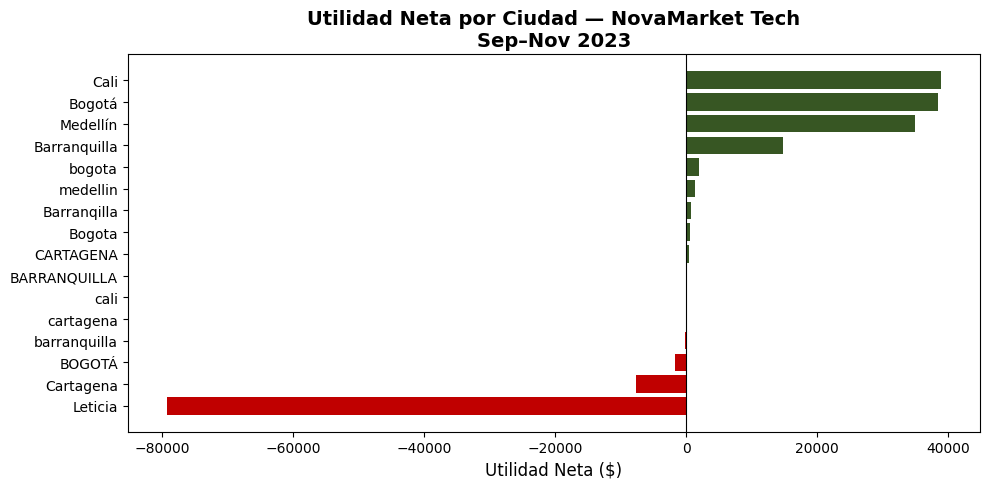

✅ Gráfico 1 guardado


In [3]:
plt.figure(figsize=(10, 5))

colores = ['#C00000' if x < 0 else '#375623' for x in resumen['Utilidad_Neta']]

plt.barh(
    y     = resumen['Ciudad'],
    width = resumen['Utilidad_Neta'],
    color = colores
)

plt.xlabel('Utilidad Neta ($)', fontsize=12)
plt.title('Utilidad Neta por Ciudad — NovaMarket Tech\nSep–Nov 2023', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('grafico1_utilidad_ciudades.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Gráfico 1 guardado')

/tmp/ipykernel_4115/4266658216.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


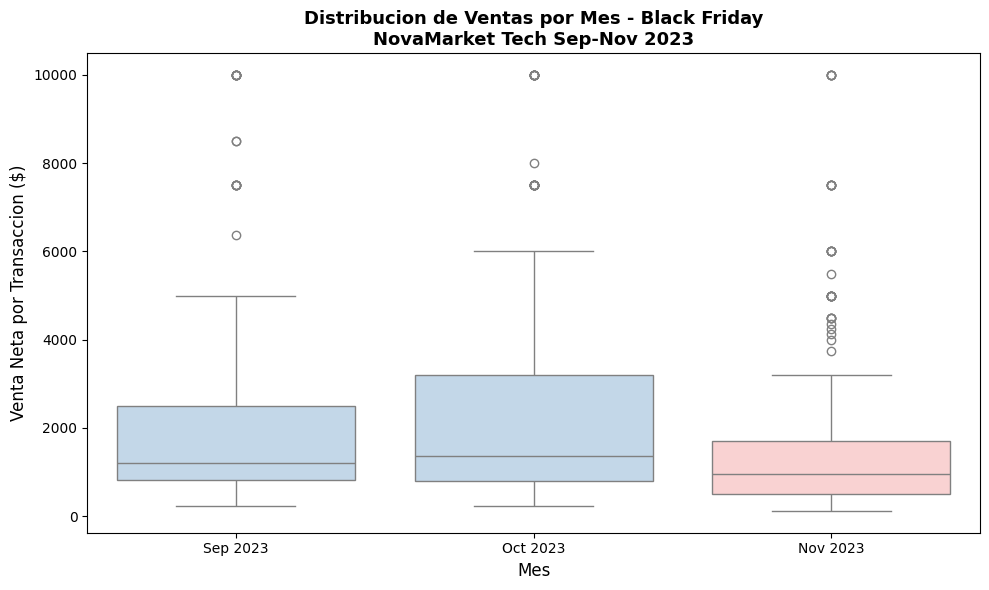

Grafico 2 guardado


In [6]:
df['Mes'] = df['Fecha'].dt.strftime('%b %Y')
orden_meses = ['Sep 2023', 'Oct 2023', 'Nov 2023']

plt.figure(figsize=(10, 6))

sns.boxplot(
    data    = df,
    x       = 'Mes',
    y       = 'Venta_Neta',
    order   = orden_meses,
    palette = ['#BDD7EE', '#BDD7EE', '#FFCCCC']
)

plt.xlabel('Mes', fontsize=12)
plt.ylabel('Venta Neta por Transaccion ($)', fontsize=12)
plt.title('Distribucion de Ventas por Mes - Black Friday\nNovaMarket Tech Sep-Nov 2023', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico2_boxplot_meses.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grafico 2 guardado')

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_l'

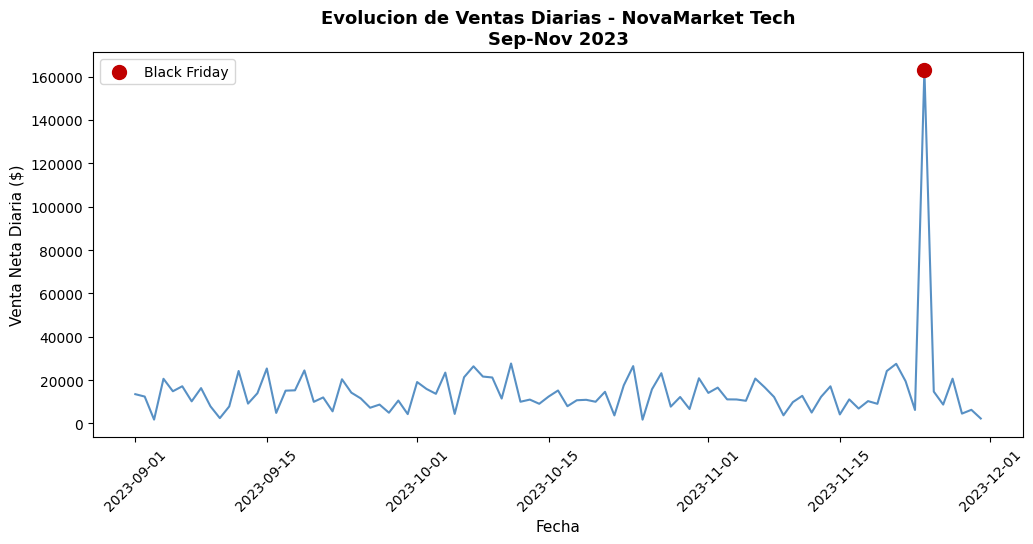

In [7]:
ventas_diarias = df.groupby('Fecha')['Venta_Neta'].sum().reset_index()
ventas_diarias.columns = ['Fecha', 'Venta_Diaria']

plt.figure(figsize=(12, 5))

plt.plot(
    ventas_diarias['Fecha'],
    ventas_diarias['Venta_Diaria'],
    color     = '#2E75B6',
    linewidth = 1.5,
    alpha     = 0.8
)

bf_fecha = pd.Timestamp('2023-11-24')
bf_venta = ventas_diarias[ventas_diarias['Fecha']==bf_fecha]['Venta_Diaria'].values
if len(bf_venta) > 0:
    plt.scatter(bf_fecha, bf_venta[0], color='#C00000', s=100, zorder=5, label='Black Friday')
    plt.legend()

plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Venta Neta Diaria ($)', fontsize=11)
plt.title('Evolucion de Ventas Diarias - NovaMarket Tech\nSep-Nov 2023', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_l

In [8]:
plt.savefig('grafico3_linea_tiempo.png', dpi=150, bbox_inches='tight')
print('Grafico 3 guardado')

Grafico 3 guardado


<Figure size 640x480 with 0 Axes>

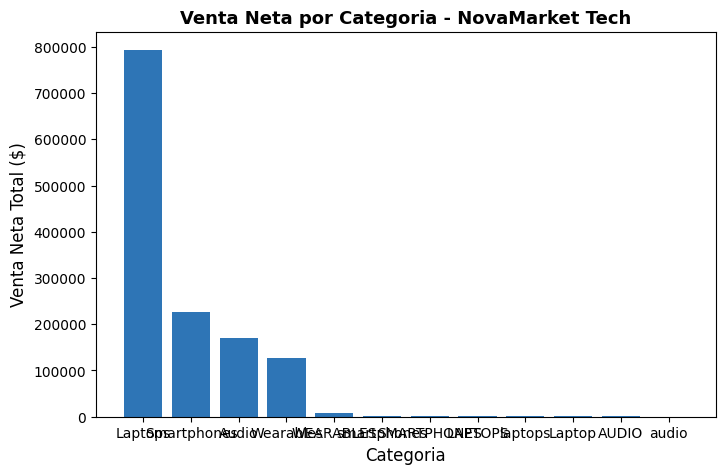

Desafio 1 guardado


In [9]:
# Desafio 1 - Venta neta por categoria
ventas_categoria = df.groupby('Categoria')['Venta_Neta'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(ventas_categoria.index, ventas_categoria.values, color='#2E75B6')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Venta Neta Total ($)', fontsize=12)
plt.title('Venta Neta por Categoria - NovaMarket Tech', fontsize=13, fontweight='bold')
plt.savefig('desafio1_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Desafio 1 guardado')

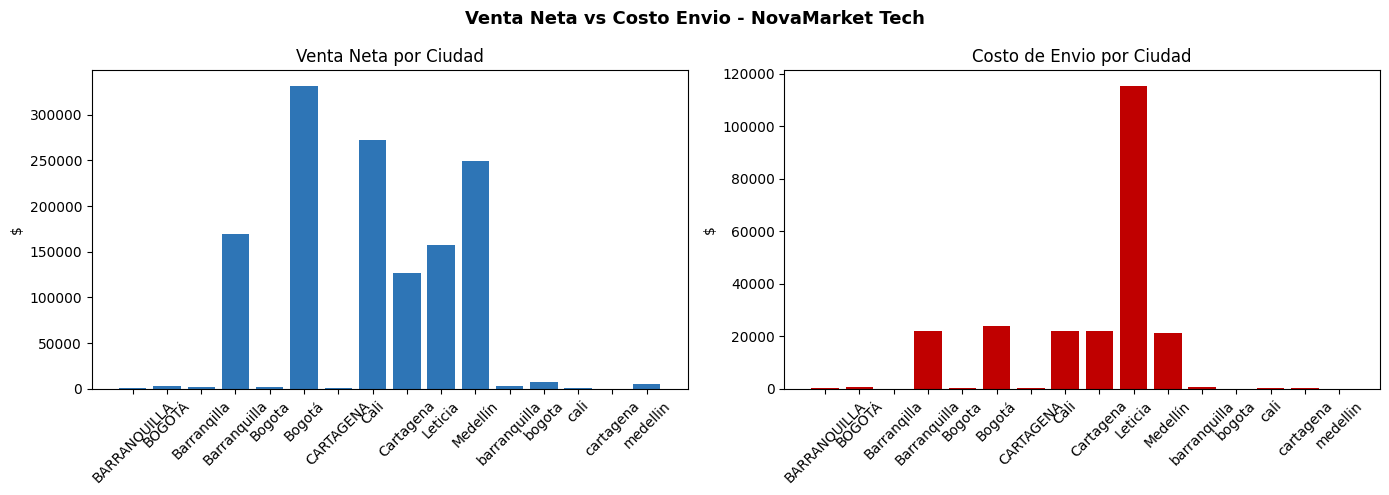

Desafio 2 guardado


In [10]:
# Desafio 2 - Venta neta vs Costo de envio por ciudad
resumen2 = df.groupby('Ciudad').agg(
    Venta_Neta   = ('Venta_Neta',   'sum'),
    Costo_Envio  = ('Costo_Envio',  'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(resumen2['Ciudad'], resumen2['Venta_Neta'], color='#2E75B6')
ax1.set_title('Venta Neta por Ciudad')
ax1.set_ylabel('$')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(resumen2['Ciudad'], resumen2['Costo_Envio'], color='#C00000')
ax2.set_title('Costo de Envio por Ciudad')
ax2.set_ylabel('$')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Venta Neta vs Costo Envio - NovaMarket Tech', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('desafio2_venta_vs_envio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Desafio 2 guardado')